In [88]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys         
import xarray as xr
sys.path.insert(0, '../defs/')
from defs import NooneCurves as NC 
from defs import NooneCurves_ax as NC_ax
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [89]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [90]:
band = 'S'
bandin = 's'
bands = {'N':[5,12,10,31],'EQ':[-5,5,10,29],'S':[-15,-5,12,31]}
chunk = 30

filename_add = '_full_ts'

datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
sat_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/F4R_data/tes_'+bandin+'_cb_007.nc')
sat_ds = sat_ds.rename({'timedatum':'time'})

onset1 = {'N':125,'EQ':62,'S':290}
onset2 = {'N':'a','EQ':247,'S':'a'}
cessation1 = {'N':297,'EQ':142,'S':111}
cessation2 = {'N':'a','EQ':341,'S':'b'}

sat_ds = sat_ds.where((sat_ds['pressure']>=650)&(sat_ds['pressure']<=850),drop=True)
#sat_ds = sat_ds.sel(time=slice('2018-01-01','2024-12-31'))

## Monthly Climatology

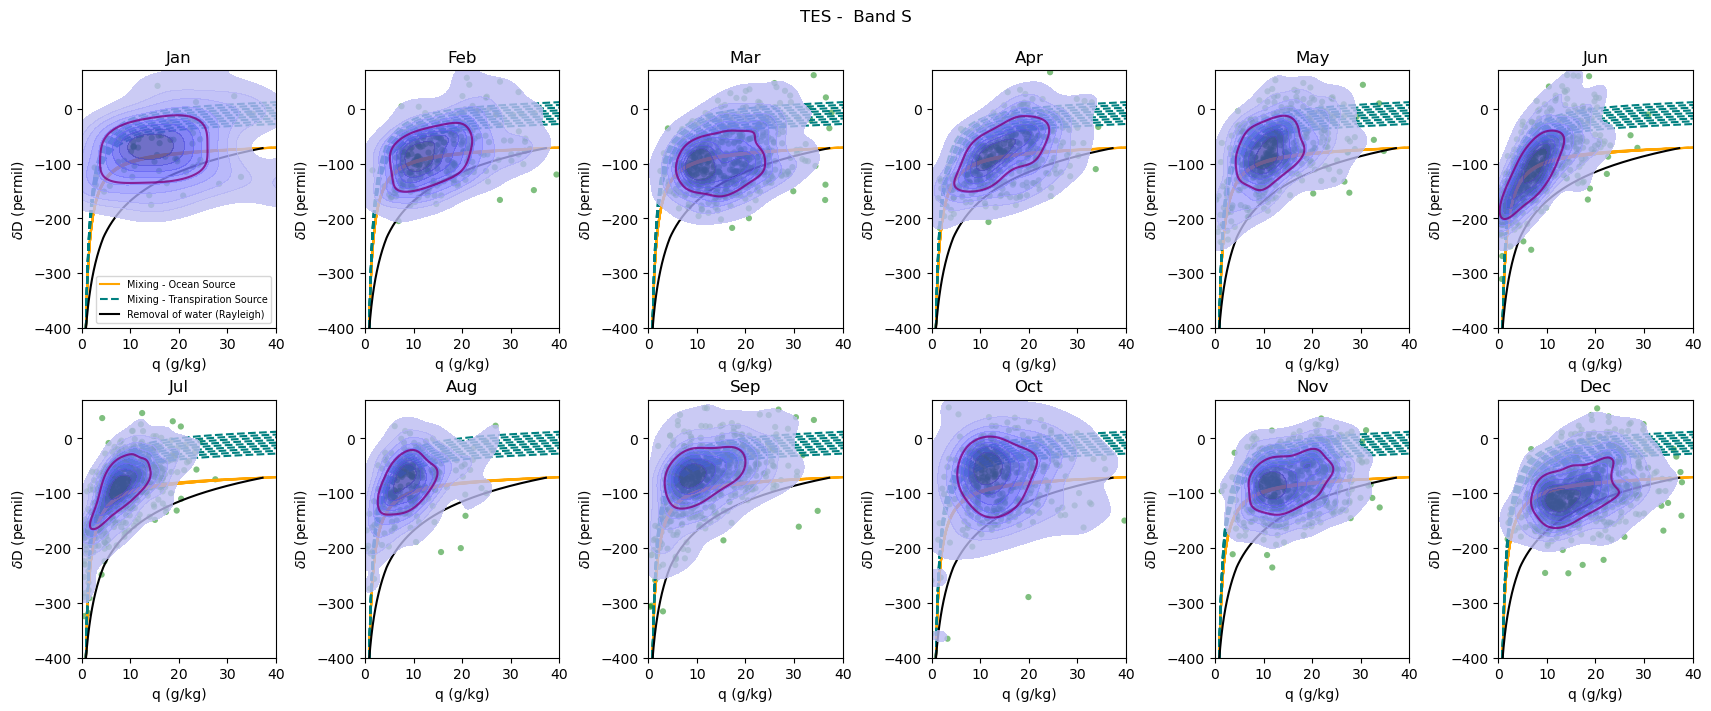

In [91]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=6
nrows=2
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(17,7))
axs=axs.flatten()

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i,s in enumerate(months):
    
    df = sat_ds.sel(time=(sat_ds.time.dt.month==i+1), drop=True).to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs[i],zorder=1)
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=False,
                    alpha=0.8,color='purple',ax=axs[i],zorder=1,levels=[0.5],label='50%')
    #sns.kdeplot(data=df, x="H2O", y="deltaD", fill=False,
    #                alpha=0.8,color='blue',ax=axs[i],zorder=1,levels=[0.2])
    axs[i].set_xlim(0,40)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(df['H2O'],df['deltaD'],s=20,alpha=0.5,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='lower right',fontsize='x-small')
plt.suptitle('TES -  Band '+band+'\n')
plt.savefig(datap+'TES_noone_curves_'+bandin+filename_add+'.png',transparent=True)

plt.show()
plt.clf()
plt.close()

## Season 1 

In [92]:
ON = onset1[band]
CE = cessation1[band]

seas_avg = sat_ds.where((sat_ds['time.dayofyear']>ON)&(sat_ds['time.dayofyear']<CE),drop=True)

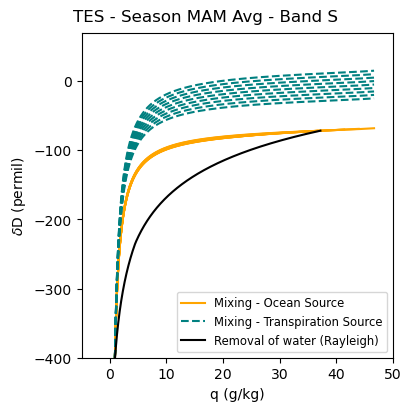

In [93]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,4))
    
df = seas_avg.to_dataframe()
df['H2O'] = df['H2O']*1000.

sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs)
sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs,zorder=1,thresh=.2)
axs.set_xlim(-5,50)
axs.set_ylim(-400,70)
axs.scatter(1000.*seas_avg['H2O'],seas_avg['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=0)
NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
axs.legend(loc='best',fontsize='small')
plt.suptitle('TES - Season MAM Avg - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TES_noone_curves_'+band+'_S1_avg.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 1 Onset

In [94]:
seas1 = {}

#seas1[str((chunk*3))+'-'+str((chunk*2))+' days pre-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*3)))&(sat_ds['time.dayofyear']<(ON-(chunk*2))),drop=True)
seas1[str((chunk*2))+'-'+str((chunk*1))+' days to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*2)))&(sat_ds['time.dayofyear']<(ON-(chunk*1))),drop=True)
seas1[str((chunk*1))+' days pre-onset to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*1)))&(sat_ds['time.dayofyear']<(ON)),drop=True)
seas1['Onset to '+str(chunk*1)+' days post-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON))&(sat_ds['time.dayofyear']<(ON+(chunk*1))),drop=True)

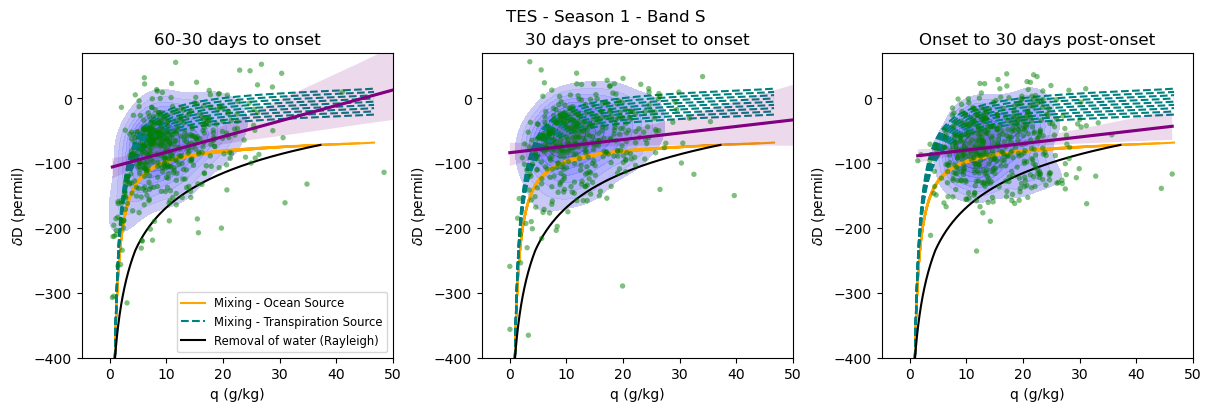

In [95]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(12,4))
axs=axs.flatten()
for i,s in enumerate(seas1):
    
    df = seas1[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.

    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.8,color='blue',ax=axs[i],zorder=0,thresh=.2)
    axs[i].set_xlim(-5,50)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(1000.*seas1[s]['H2O'],seas1[s]['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=1)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TES - Season 1 - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TES_noone_curves_'+band+'_S1_ON.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 1 Cessation

In [96]:
seas1 = {}

seas1[str((chunk*2))+'-'+str((chunk*1))+' days to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*2)))&(sat_ds['time.dayofyear']<(CE-(chunk*1))),drop=True)
seas1[str((chunk*1))+' days to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*1)))&(sat_ds['time.dayofyear']<(CE)),drop=True)
seas1['Cessation to '+str(chunk*1)+' days post-cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE))&(sat_ds['time.dayofyear']<(CE+(chunk*1))),drop=True)


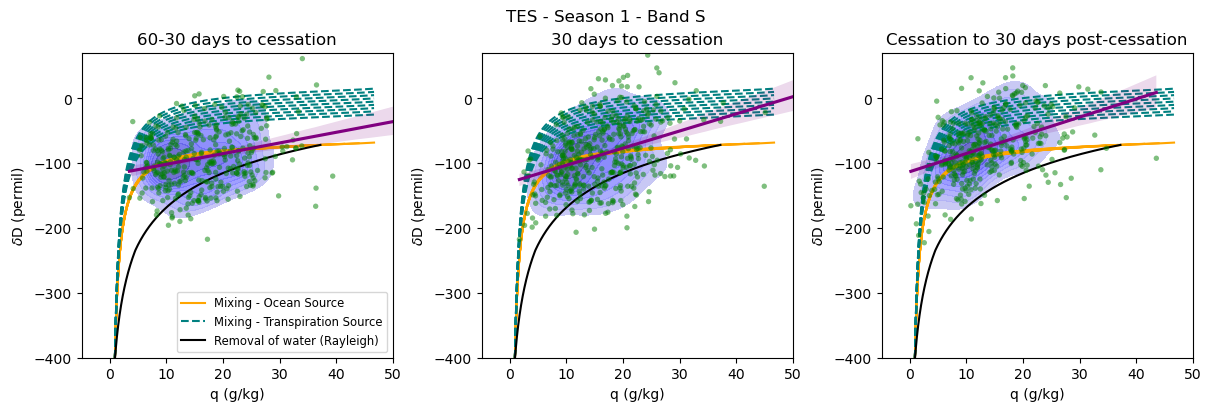

In [97]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(12,4))
axs=axs.flatten()
for i,s in enumerate(seas1):
    
    df = seas1[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.

    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.8,color='blue',ax=axs[i],zorder=0,thresh=.2)
    axs[i].set_xlim(-5,50)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(1000.*seas1[s]['H2O'],seas1[s]['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=1)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TES - Season 1 - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TES_noone_curves_'+band+'_S1_CE.png',transparent=True)

plt.show()
plt.clf()
plt.close()

## Season 2

In [98]:
ON = onset2[band]
CE = cessation2[band]

seas_avg = sat_ds.where((sat_ds['time.dayofyear']>ON)&(sat_ds['time.dayofyear']<CE),drop=True)

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

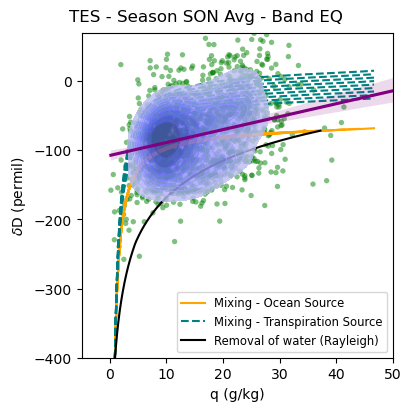

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,4))
    
df = seas_avg.to_dataframe()
df['H2O'] = df['H2O']*1000.

sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs)
sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs,zorder=1,thresh=.2)
axs.set_xlim(-5,50)
axs.set_ylim(-400,70)
axs.scatter(1000.*seas_avg['H2O'],seas_avg['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=0)
NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
axs.legend(loc='best',fontsize='small')
plt.suptitle('TES - Season SON Avg - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TES_noone_curves_'+band+'_S2_avg.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 2 Onset

In [ ]:
seas2 = {}

#seas2[str((chunk*3))+'-'+str((chunk*2))+' days pre-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*3)))&(sat_ds['time.dayofyear']<(ON-(chunk*2))),drop=True)
seas2[str((chunk*2))+'-'+str((chunk*1))+' days to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*2)))&(sat_ds['time.dayofyear']<(ON-(chunk*1))),drop=True)
seas2[str((chunk*1))+' days pre-onset to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*1)))&(sat_ds['time.dayofyear']<(ON)),drop=True)
seas2['Onset to '+str(chunk*1)+' days post-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON))&(sat_ds['time.dayofyear']<(ON+(chunk*1))),drop=True)

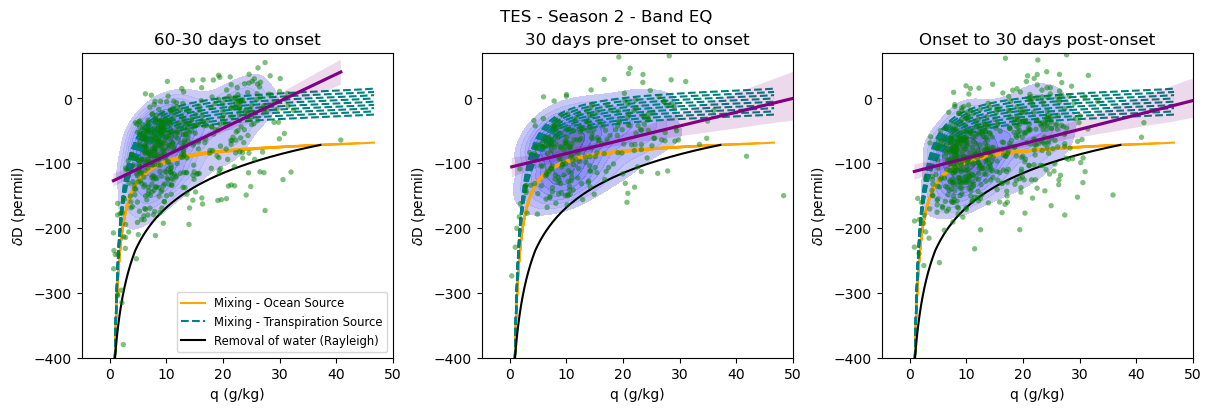

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(12,4))
axs=axs.flatten()
for i,s in enumerate(seas2):
    
    df = seas2[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.

    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.8,color='blue',ax=axs[i],zorder=0,thresh=.2)
    axs[i].set_xlim(-5,50)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(1000.*seas2[s]['H2O'],seas2[s]['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=1)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TES - Season 2 - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TES_noone_curves_'+band+'_S2_ON.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 2 Cessation

In [ ]:
seas2 = {}

seas2[str((chunk*2))+'-'+str((chunk*1))+' days to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*2)))&(sat_ds['time.dayofyear']<(CE-(chunk*1))),drop=True)
seas2[str((chunk*1))+' days pre-cessation to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*1)))&(sat_ds['time.dayofyear']<(CE)),drop=True)
seas2['Cessation to '+str(chunk*1)+' days post-cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE))&(sat_ds['time.dayofyear']<(CE+(chunk*1))),drop=True)

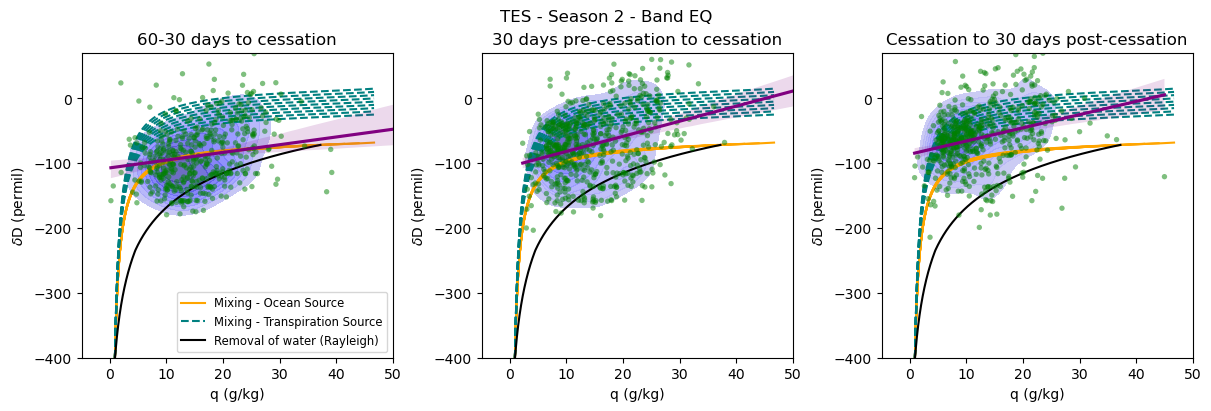

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(12,4))
axs=axs.flatten()
for i,s in enumerate(seas2):
    
    df = seas2[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.

    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.8,color='blue',ax=axs[i],zorder=0,thresh=.2)
    axs[i].set_xlim(-5,50)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(1000.*seas2[s]['H2O'],seas2[s]['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=1)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TES - Season 2 - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TES_noone_curves_'+band+'_S2_CE.png',transparent=True)

plt.show()
plt.clf()
plt.close()